In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
customers = pd.read_csv(r"C:\ddrive\jpmorgan\banking-data-portfolio\custmoer-transaction-sql-analysis\data\customers.csv")

accounts = pd.read_csv(r"C:\ddrive\jpmorgan\banking-data-portfolio\custmoer-transaction-sql-analysis\data\accounts.csv")

transactions = pd.read_csv(r"C:\ddrive\jpmorgan\banking-data-portfolio\custmoer-transaction-sql-analysis\data\Comprehensive_Banking_Database.csv")

customers.head()
accounts.head()
transactions.tail()

,Customer ID,First Name,Last Name,Age,Gender,Address,City,Contact Number,Email,Account Type,...,Minimum Payment Due,Payment Due Date,Last Credit Card Payment Date,Rewards Points,Feedback ID,Feedback Date,Feedback Type,Resolution Status,Resolution Date,Anomaly
4995,4996,Emily,Sanchez,21,Other,Address_4996,Mesa,19458799849,emily.sanchez@kag.com,Savings,...,100.86,7/19/2023,2/10/2023,7530,4996,4/12/2023,Complaint,Pending,1/23/2023,1
4996,4997,Melissa,Perez,27,Female,Address_4997,Los Angeles,19458799850,melissa.perez@kag.com,Savings,...,42.67,2/16/2023,12/24/2023,8796,4997,9/7/2023,Complaint,Pending,9/17/2023,1
4997,4998,Timothy,Walker,45,Female,Address_4998,Louisville,19458799851,timothy.walker@kag.com,Current,...,11.42,2/23/2023,9/6/2023,9966,4998,10/23/2023,Suggestion,Resolved,2/5/2023,1
4998,4999,Deborah,Nelson,58,Female,Address_4999,Detroit,19458799852,deborah.nelson@kag.com,Current,...,16.27,9/8/2023,1/12/2023,538,4999,5/20/2023,Complaint,Pending,3/3/2023,1
4999,5000,Daniel,Martinez,35,Male,Address_5000,El Paso,19458799853,daniel.martinez@kag.com,Current,...,153.90,5/30/2023,6/3/2023,1816,5000,9/6/2023,Suggestion,Resolved,5/23/2023,1


In [43]:
customers.info()
accounts.info()
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   customer_id   50000 non-null  str  
 1   first_name    50000 non-null  str  
 2   last_name     50000 non-null  str  
 3   email         50000 non-null  str  
 4   city          50000 non-null  str  
 5   credit_score  50000 non-null  int64
 6   created_at    50000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 2.7 MB
<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   account_id    75000 non-null  str    
 1   customer_id   75000 non-null  str    
 2   account_type  75000 non-null  str    
 3   balance_usd   75000 non-null  float64
 4   open_date     75000 non-null  str    
dtypes: float64(1), str(4)
memory usage: 2.9 MB
<class 'pandas.DataFrame'>
RangeIndex: 500

In [44]:
customers.columns
accounts.columns
transactions.columns

Index(['Customer ID', 'First Name', 'Last Name', 'Age', 'Gender', 'Address',
       'City', 'Contact Number', 'Email', 'Account Type', 'Account Balance',
       'Date Of Account Opening', 'Last Transaction Date', 'TransactionID',
       'Transaction Date', 'Transaction Type', 'Transaction Amount',
       'Account Balance After Transaction', 'Branch ID', 'Loan ID',
       'Loan Amount', 'Loan Type', 'Interest Rate', 'Loan Term',
       'Approval/Rejection Date', 'Loan Status', 'CardID', 'Card Type',
       'Credit Limit', 'Credit Card Balance', 'Minimum Payment Due',
       'Payment Due Date', 'Last Credit Card Payment Date', 'Rewards Points',
       'Feedback ID', 'Feedback Date', 'Feedback Type', 'Resolution Status',
       'Resolution Date', 'Anomaly'],
      dtype='str')

In [45]:
customers.isnull().sum()
accounts.isnull().sum()
transactions.isnull().sum()

Customer ID                          0
First Name                           0
Last Name                            0
Age                                  0
Gender                               0
Address                              0
City                                 0
Contact Number                       0
Email                                0
Account Type                         0
Account Balance                      0
Date Of Account Opening              0
Last Transaction Date                0
TransactionID                        0
Transaction Date                     0
Transaction Type                     0
Transaction Amount                   0
Account Balance After Transaction    0
Branch ID                            0
Loan ID                              0
Loan Amount                          0
Loan Type                            0
Interest Rate                        0
Loan Term                            0
Approval/Rejection Date              0
Loan Status              

In [46]:
customers.head()

,customer_id,first_name,last_name,email,city,credit_score,created_at
0,CUSXAJI0Y6DPBHS,Kevin,Young,brauncameron@example.net,North Williamville,327,2025-04-17
1,CUSHXTHV3A3ZMF8,Jason,Clements,toddwilliam@example.net,Martinezside,644,2020-02-23
2,CUSDD4V30T9NT3W,Randy,Thompson,trevoranderson@example.org,Gallowayfurt,670,2025-06-22
3,CUSGCX1945NQ4FM,Laura,Phillips,valdezgeorge@example.com,Morrisview,573,2019-10-20
4,CUSVG0FN9XUY41I,Savannah,Swanson,smithluis@example.com,Lake Anna,332,2022-07-16


In [47]:
customers.columns

Index(['customer_id', 'first_name', 'last_name', 'email', 'city',
       'credit_score', 'created_at'],
      dtype='str')

In [48]:
import pandas as pd
import sqlite3

# load dataset
customers = pd.read_csv("../data/customers.csv")

# combine first and last name
customers["customer_name"] = customers["first_name"] + " " + customers["last_name"]

# select relevant columns
customers_clean = customers[
    [
        "customer_id",
        "customer_name",
        "email",
        "city",
        "credit_score",
        "created_at"
    ]
]

# connect database
con = sqlite3.connect("my_database.db")

# create customers table
customers_clean.to_sql(
    "customers",
    con,
    if_exists="replace",
    index=False
)

con.close()

print("customers table has been  created successfully")

customers table has been  created successfully


In [49]:
con = sqlite3.connect("my_database.db")

query = """
SELECT * FROM customers
LIMIT 10
"""

df = pd.read_sql(query, con)

con.close()

df.head()

,customer_id,customer_name,email,city,credit_score,created_at
0,CUSXAJI0Y6DPBHS,Kevin Young,brauncameron@example.net,North Williamville,327,2025-04-17
1,CUSHXTHV3A3ZMF8,Jason Clements,toddwilliam@example.net,Martinezside,644,2020-02-23
2,CUSDD4V30T9NT3W,Randy Thompson,trevoranderson@example.org,Gallowayfurt,670,2025-06-22
3,CUSGCX1945NQ4FM,Laura Phillips,valdezgeorge@example.com,Morrisview,573,2019-10-20
4,CUSVG0FN9XUY41I,Savannah Swanson,smithluis@example.com,Lake Anna,332,2022-07-16


In [50]:
# load dataset
accounts = pd.read_csv("../data/accounts.csv")

# select relevant columns
accounts_clean = accounts[
    [
        "account_id",
        "customer_id",
        "account_type",
        "balance_usd",
        "open_date",
        
    ]
]

# connect database
con = sqlite3.connect("my_database.db")

# create accounts table
accounts_clean.to_sql(
    "accounts",
    con,
    if_exists="replace",
    index=False
)

con.close()

print("accounts table created successfully")

accounts table created successfully


In [51]:
con = sqlite3.connect("my_database.db")

query = """
SELECT * FROM accounts
LIMIT 10
"""

df = pd.read_sql(query, con)

con.close()

df.head()

,account_id,customer_id,account_type,balance_usd,open_date
0,ACCOD48PUCAEHKH,CUSAEOACKBH8CK6,Checking,182700.46,2021-03-27
1,ACCU2DMTSOYD5R6,CUSKI0ABUBGCLFD,Savings,57886.71,2019-10-21
2,ACCXFI6TF26FL9B,CUSWXG0ESCUG77M,Business,68774.44,2019-02-15
3,ACCJ6SUS4ZI6BRT,CUSUTT52LK3TW0J,Business,67015.68,2021-10-30
4,ACCNP7JE3AQW8TG,CUSNUWQT2EXWNSC,Savings,67265.67,2023-12-05


In [52]:
import pandas as pd
import sqlite3

# load dataset
transactions = pd.read_csv("../data/Comprehensive_Banking_Database.csv")

# select relevant columns
transactions_clean = transactions[
    [
        "TransactionID",
        "Customer ID",
        "Account Type",
        "Transaction Date",
        "Transaction Type",
        "Transaction Amount",
        "Account Balance After Transaction"
    ]
]

# rename columns to database formats are 
transactions_clean.columns = [
    "transaction_id",
    "customer_id",
    "account_type",
    "transaction_date",
    "transaction_type",
    "amount",
    "balance_after_transaction"
]

# connect database
con = sqlite3.connect("my_database.db")

# create tranasctins table
transactions_clean.to_sql(
    "transactions",
    con,
    if_exists="replace",
    index=False
)

con.close()

print("transactions table created successfully")

transactions table created successfully


In [53]:
con = sqlite3.connect("my_database.db")

query = """
SELECT * FROM transactions
LIMIT 10
"""

df = pd.read_sql(query, con)

con.close()

df.head()

,transaction_id,customer_id,account_type,transaction_date,transaction_type,amount,balance_after_transaction
0,1,1,Current,12/7/2023,Withdrawal,1457.61,2770.99
1,2,2,Current,4/27/2023,Deposit,1660.99,7649.45
2,3,3,Current,4/5/2023,Deposit,839.91,7437.97
3,4,4,Savings,7/28/2023,Withdrawal,4908.89,12396.10
4,5,5,Savings,1/16/2023,Transfer,589.07,6404.48


In [54]:
merged_data = transactions.copy()

merged_data.to_csv("../data/final_dataset.csv", index=False)

print("final_dataset.csv created successfully")

final_dataset.csv created successfully


Text(0.5, 1.0, 'My first plotting Rewards Points')

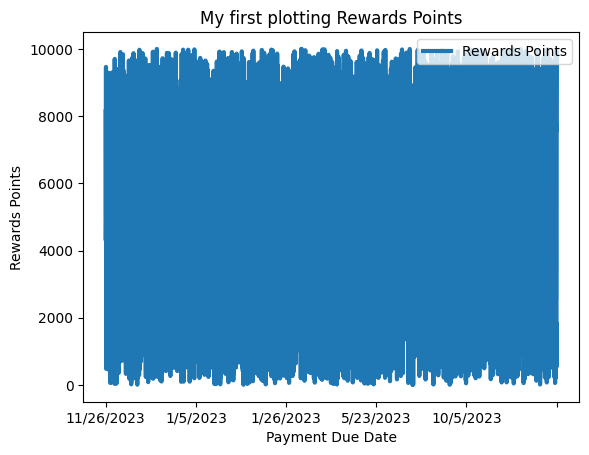

In [55]:
# Final csv
final_ds = pd.read_csv(r"C:\ddrive\jpmorgan\banking-data-portfolio\custmoer-transaction-sql-analysis\data\final_dataset.csv")
final_ds.head()

# 
final_ds.plot(x = 'Payment Due Date', y = 'Rewards Points', label = 'Rewards Points', linewidth = 3)
plt.ylabel('Rewards Points')
plt.legend(loc = 'upper right')
plt.title('My first plotting Rewards Points')

In [56]:
import sqlite3
import pandas as pd

con = sqlite3.connect("my_database.db")

query = """
SELECT
c.customer_name,
t.account_type,
t.transaction_type,
t.amount,
t.transaction_date
FROM customers c
JOIN transactions t
ON c.customer_id = t.customer_id
LIMIT 10
"""

df = pd.read_sql(query, con)

con.close()

df.head()

,customer_name,account_type,transaction_type,amount,transaction_date


In [57]:

con = sqlite3.connect("my_database.db")

query = """
SELECT
customer_id,
SUM(amount) AS total_spent
FROM transactions
GROUP BY customer_id
ORDER BY total_spent DESC;
"""

df = pd.read_sql(query, con)

con.close()

df.head()

,customer_id,total_spent
0,4981,4998.39
1,2817,4998.29
2,1137,4998.12
3,1418,4997.52
4,845,4997.37


In [58]:
con = sqlite3.connect("my_database.db")

query = """
SELECT
account_type,
AVG(amount) AS avg_transaction
FROM transactions
GROUP BY account_type;
"""

df = pd.read_sql(query, con)

con.close()

df.head()

,account_type,avg_transaction
0,Current,2526.815552
1,Savings,2490.289011


In [59]:
con = sqlite3.connect("my_database.db")

query = """
SELECT
transaction_date,
SUM(amount) AS total_amount
FROM transactions
GROUP BY transaction_date
ORDER BY transaction_date;
"""

df = pd.read_sql(query, con)

con.close()

df.head()

,transaction_date,total_amount
0,1/1/2023,24681.51
1,1/10/2023,34254.20
2,1/11/2023,38600.38
3,1/12/2023,36672.18
4,1/13/2023,28196.56


In [60]:
merged_data.to_csv("../data/final_dataset.csv", index=False)